# Zinc Adsorption: Linear vs Nonlinear Regression

Langmuir, Freundlich, and Temkin isotherm models for soil samples 50, 52, and 62, including linear/nonlinear fitting, correlation coefficients, goodness-of-fit metrics, residual diagnostics, plots with units, and Excel export.

In [23]:
# # Zinc adsorption: linear vs nonlinear isotherm regression

In [24]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
from statsmodels.stats.stattools import durbin_watson

warnings.filterwarnings('ignore')

DATA_FILE = 'exccc1 (2).xlsx'   # <-- change if necessary
TARGET_SHEETS = ['50', '52', '62']

xls = pd.ExcelFile(DATA_FILE)
print('Available sheets:', xls.sheet_names)

Available sheets: ['50', '62', '52']


In [25]:
# Langmuir: qe = (qm * KL * Ce) / (1 + KL * Ce)
def langmuir(Ce, qm, KL):
    return (qm * KL * Ce) / (1.0 + KL * Ce)

# Freundlich: qe = KF * Ce^(1/n)
def freundlich(Ce, KF, n):
    return KF * np.power(Ce, 1.0 / n)

# Temkin: qe = B * ln(A * Ce)
def temkin(Ce, A, B):
    return B * np.log(A * Ce)

NONLINEAR_MODELS = {
    'Langmuir': langmuir,
    'Freundlich': freundlich,
    'Temkin': temkin,
}

In [26]:
def read_isotherm_data(file_path, sheet):
    df = pd.read_excel(file_path, sheet_name=sheet)

    required = ['Ce mean', 'qe(R1)', 'qe(R2)', 'qe(R3)']
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f'Sheet {sheet}: missing columns: {missing}')

    out = df[required].copy()
    out['qe_mean_from_replicates'] = out[['qe(R1)', 'qe(R2)', 'qe(R3)']].mean(axis=1, skipna=True)

    # Prefer the existing qe mean only where it is present; otherwise use R1-R3 mean.
    if 'qe mean' in df.columns:
        out['qe'] = df['qe mean'].where(df['qe mean'].notna(), out['qe_mean_from_replicates'])
    else:
        out['qe'] = out['qe_mean_from_replicates']

    out = out[['Ce mean', 'qe']].rename(columns={'Ce mean': 'Ce'})
    out = out.replace([np.inf, -np.inf], np.nan).dropna()
    out = out[(out['Ce'] > 0) & (out['qe'] > 0)].copy()
    return out

def fit_linear_models(Ce, qe):
    results = {}

    # Langmuir linear form: Ce/qe = (1/qm) Ce + 1/(qm KL)
    p = np.polyfit(Ce, Ce / qe, 1)
    slope, intercept = p
    qm = 1.0 / slope
    KL = slope / intercept
    pred = (qm * KL * Ce) / (1 + KL * Ce)
    results['Langmuir'] = {'params': {'qm': qm, 'KL': KL}, 'pred': pred}

    # Freundlich linear form: log10(qe) = log10(KF) + (1/n) log10(Ce)
    p = np.polyfit(np.log10(Ce), np.log10(qe), 1)
    slope, intercept = p
    n = 1.0 / slope
    KF = 10.0 ** intercept
    pred = KF * np.power(Ce, 1.0 / n)
    results['Freundlich'] = {'params': {'KF': KF, 'n': n}, 'pred': pred}

    # Temkin linear form: qe = B ln(A) + B ln(Ce) = slope ln(Ce) + intercept
    p = np.polyfit(np.log(Ce), qe, 1)
    B = p[0]
    A = np.exp(p[1] / B) if B != 0 else np.nan
    pred = B * np.log(A * Ce)
    results['Temkin'] = {'params': {'A': A, 'B': B}, 'pred': pred}

    return results

def initial_guesses(Ce, qe):
    qmax = max(np.max(qe) * 1.2, np.max(qe) + 1e-6)
    ce_med = np.median(Ce)
    qe_med = np.median(qe)

    # Reasonable positive starting values.
    return {
        'Langmuir': [qmax, 1.0 / max(ce_med, 1e-12)],
        'Freundlich': [qe_med / max(ce_med ** 0.5, 1e-12), 2.0],
        'Temkin': [max(1.0 / max(ce_med, 1e-12), 1e-12), max(qe_med, 1e-12)],
    }

def fit_nonlinear_models(Ce, qe):
    starts = initial_guesses(Ce, qe)
    fits = {}

    # Wide positive bounds; increase the upper bound if your units require it.
    bounds = {
        'Langmuir': ([1e-12, 1e-12], [np.inf, np.inf]),
        'Freundlich': ([1e-12, 1e-6], [np.inf, np.inf]),
        'Temkin': ([1e-12, 1e-12], [np.inf, np.inf]),
    }

    for name, func in NONLINEAR_MODELS.items():
        popt, pcov = curve_fit(
            func, Ce, qe,
            p0=starts[name],
            bounds=bounds[name],
            maxfev=100000
        )
        pred = func(Ce, *popt)
        fits[name] = {'popt': popt, 'pcov': pcov, 'pred': pred}

    return fits

def statistics(y, pred, k):
    residuals = y - pred
    n = len(y)
    sse = np.sum(residuals ** 2)
    rmse = np.sqrt(np.mean(residuals ** 2))
    mae = np.mean(np.abs(residuals))
    r2 = r2_score(y, pred)

    # Pearson correlation coefficient between experimental and predicted qe.
    # This is useful as a correlation measure, while R2 remains the goodness-of-fit metric.
    if len(y) > 1 and np.std(y) > 0 and np.std(pred) > 0:
        r = np.corrcoef(y, pred)[0, 1]
    else:
        r = np.nan

    chi2 = np.sum((residuals ** 2) / np.maximum(np.abs(pred), 1e-12))
    aic = n * np.log(max(sse / n, 1e-300)) + 2 * k
    bic = n * np.log(max(sse / n, 1e-300)) + k * np.log(n)
    return {'R': r, 'R2': r2, 'SSE': sse, 'RMSE': rmse, 'MAE': mae,
            'Chi2': chi2, 'AIC': aic, 'BIC': bic}

In [27]:
for sheet in TARGET_SHEETS:
    d = read_isotherm_data(DATA_FILE, sheet)
    print(f'Sheet {sheet}: n = {len(d)}')
    display(d.head())

Sheet 50: n = 8


,Ce,qe
0,0.037932,3.999949
1,0.033675,7.254257
2,0.328507,18.587064
3,0.465994,19.098093
4,0.795860,23.447028


Sheet 52: n = 8


,Ce,qe
0,0.035255,5.357143
1,0.023631,7.002906
2,0.114544,13.175453
3,0.365861,19.028755
4,0.707828,29.425240


Sheet 62: n = 8


,Ce,qe
0,0.041221,5.297492
1,0.058530,6.653921
2,0.201387,12.307026
3,0.320519,19.482173
4,0.583427,30.669250


In [28]:
all_results = []
parameter_results = []

for sheet in TARGET_SHEETS:
    data = read_isotherm_data(DATA_FILE, sheet)
    Ce = data['Ce'].to_numpy(dtype=float)
    qe = data['qe'].to_numpy(dtype=float)
        
    linear = fit_linear_models(Ce, qe)
    nonlinear = fit_nonlinear_models(Ce, qe)
        
    for model in NONLINEAR_MODELS:
        # Two parameters for all three models.
        st = statistics(qe, linear[model]['pred'], k=2)
        all_results.append({'Soil': sheet, 'Model': model, 'Method': 'Linear', **st})

        st = statistics(qe, nonlinear[model]['pred'], k=2)
        all_results.append({'Soil': sheet, 'Model': model, 'Method': 'Nonlinear', **st})

        if model == 'Langmuir':
            names = ['qm', 'KL']
        elif model == 'Freundlich':
            names = ['KF', 'n']
        else:
            names = ['A', 'B']

        row = {'Soil': sheet, 'Model': model, 'Method': 'Nonlinear'}
        row.update(dict(zip(names, nonlinear[model]['popt'])))
        parameter_results.append(row)

comparison = pd.DataFrame(all_results)
parameters = pd.DataFrame(parameter_results)

print('=== NONLINEAR PARAMETERS ===')
display(parameters.round(6))

print('=== LINEAR vs NONLINEAR PERFORMANCE ===')
display(comparison.round(6))

method_comparison = comparison.pivot_table(
    index=['Soil', 'Model'],
    columns='Method',
    values=['R', 'R2', 'SSE', 'RMSE', 'MAE', 'Chi2', 'AIC', 'BIC']
)
display(method_comparison.round(6))

# Simple evidence-based direction for each metric.
rows = []
for (soil, model), g in comparison.groupby(['Soil', 'Model']):
    lin = g[g['Method'] == 'Linear'].iloc[0]
    non = g[g['Method'] == 'Nonlinear'].iloc[0]
    rows.append({
        'Soil': soil,
        'Model': model,
        'RMSE_better': 'Nonlinear' if non.RMSE < lin.RMSE else 'Linear',
        'R2_better': 'Nonlinear' if non.R2 > lin.R2 else 'Linear',
        'AIC_better': 'Nonlinear' if non.AIC < lin.AIC else 'Linear',
        'BIC_better': 'Nonlinear' if non.BIC < lin.BIC else 'Linear',
    })

direction_table = pd.DataFrame(rows)
display(direction_table)

=== NONLINEAR PARAMETERS ===


,Soil,Model,Method,qm,KL,KF,n,A,B
0,50,Langmuir,Nonlinear,49.891426,1.509023,NaN,NaN,NaN,NaN
1,50,Freundlich,Nonlinear,NaN,NaN,29.060709,2.045717,NaN,NaN
2,50,Temkin,Nonlinear,NaN,NaN,NaN,NaN,49.387077,7.480582
3,52,Langmuir,Nonlinear,62.032322,1.522547,NaN,NaN,NaN,NaN
4,52,Freundlich,Nonlinear,NaN,NaN,36.324329,1.954343,NaN,NaN
5,52,Temkin,Nonlinear,NaN,NaN,NaN,NaN,52.594965,9.067951
6,62,Langmuir,Nonlinear,60.243602,1.759860,NaN,NaN,NaN,NaN
7,62,Freundlich,Nonlinear,NaN,NaN,36.718321,1.970951,NaN,NaN
8,62,Temkin,Nonlinear,NaN,NaN,NaN,NaN,27.916183,11.143743


=== LINEAR vs NONLINEAR PERFORMANCE ===


,Soil,Model,Method,R,R2,SSE,RMSE,MAE,Chi2,AIC,BIC
0,50,Langmuir,Linear,0.967535,0.931300,68.622301,2.928786,2.314202,6.618614,21.193408,21.352291
1,50,Langmuir,Nonlinear,0.980259,0.946117,53.821958,2.593790,2.090195,11.463066,19.249920,19.408803
2,50,Freundlich,Linear,0.986771,0.973465,26.504609,1.820186,1.739768,1.957419,13.583017,13.741900
3,50,Freundlich,Nonlinear,0.986764,0.973702,26.268580,1.812063,1.735079,1.876155,13.511456,13.670339
4,50,Temkin,Linear,0.957695,0.917179,82.727377,3.215730,2.833004,5.818790,22.688872,22.847755
5,50,Temkin,Nonlinear,0.957695,0.917179,82.727377,3.215730,2.833004,5.818790,22.688872,22.847755
6,52,Langmuir,Linear,0.973139,0.942927,94.685904,3.440311,2.604911,7.484522,23.768989,23.927872
7,52,Langmuir,Nonlinear,0.987821,0.960760,65.099944,2.852629,2.460324,14.924801,20.771857,20.930740
8,52,Freundlich,Linear,0.992443,0.984183,26.241173,1.811118,1.507899,1.493960,13.503105,13.661988
9,52,Freundlich,Nonlinear,0.992630,0.985261,24.452626,1.748307,1.525928,1.535501,12.938368,13.097252


AIC                   BIC                  Chi2  \
Method              Linear  Nonlinear     Linear  Nonlinear     Linear   
Soil Model                                                               
50   Freundlich  13.583017  13.511456  13.741900  13.670339   1.957419   
     Langmuir    21.193408  19.249920  21.352291  19.408803   6.618614   
     Temkin      22.688872  22.688872  22.847755  22.847755   5.818790   
52   Freundlich  13.503105  12.938368  13.661988  13.097252   1.493960   
     Langmuir    23.768989  20.771857  23.927872  20.930740   7.484522   
     Temkin      26.947415  26.947415  27.106298  27.106298  16.928939   
62   Freundlich  27.578285  25.059346  27.737168  25.218229   4.628460   
     Langmuir    19.466253  19.240774  19.625136  19.399657   2.593453   
     Temkin      25.608666  25.608666  25.767549  25.767549  13.624522   

                                 MAE                   R                  R2  \
Method           Nonlinear    Linear Nonlinear    Linear Nonlinear    Linear   
Soil Model                                                                     
50   Freundlich   1.876155  1.739768  1.735079  0.986771  0.986764  0.973465   
     Langmuir    11.463066  2.314202  2.090195  0.967535  0.980259  0.931300   
     Temkin       5.818790  2.833004  2.833004  0.957695  0.957695  0.917179   
52   Freundlich   1.535501  1.507899  1.525928  0.992443  0.992630  0.984183   
     Langmuir    14.924801  2.604911  2.460324  0.973139  0.987821  0.942927   
     Temkin      16.928937  3.627890  3.627890  0.956602  0.956602  0.915087   
62   Freundlich   4.897030  3.212850  3.065894  0.959959  0.967849  0.910461   
     Langmuir     2.601280  1.854636  1.976610  0.983845  0.984092  0.967519   
     Temkin      13.624522  3.074678  3.074678  0.964366  0.964366  0.930002   

                               RMSE                   SSE              
Method          Nonlinear    Linear Nonlinear      Linear   Nonlinear  
Soil Model                                                             
50   Freundlich  0.973702  1.820186  1.812063   26.504609   26.268580  
     Langmuir    0.946117  2.928786  2.593790   68.622301   53.821958  
     Temkin      0.917179  3.215730  3.215730   82.727377   82.727377  
52   Freundlich  0.985261  1.811118  1.748307   26.241173   24.452626  
     Langmuir    0.960760  3.440311  2.852629   94.685904   65.099944  
     Temkin      0.915087  4.196343  4.196343  140.874351  140.874351  
62   Freundlich  0.934647  4.365108  3.729257  152.433311  111.258881  
     Langmuir    0.968421  2.629098  2.592307   55.297252   53.760465  
     Temkin      0.930002  3.859515  3.859515  119.166868  119.166868

,Soil,Model,RMSE_better,R2_better,AIC_better,BIC_better
0,50,Freundlich,Nonlinear,Nonlinear,Nonlinear,Nonlinear
1,50,Langmuir,Nonlinear,Nonlinear,Nonlinear,Nonlinear
2,50,Temkin,Linear,Linear,Linear,Linear
3,52,Freundlich,Nonlinear,Nonlinear,Nonlinear,Nonlinear
4,52,Langmuir,Nonlinear,Nonlinear,Nonlinear,Nonlinear
5,52,Temkin,Linear,Linear,Linear,Linear
6,62,Freundlich,Nonlinear,Nonlinear,Nonlinear,Nonlinear
7,62,Langmuir,Nonlinear,Nonlinear,Nonlinear,Nonlinear
8,62,Temkin,Nonlinear,Nonlinear,Nonlinear,Nonlinear


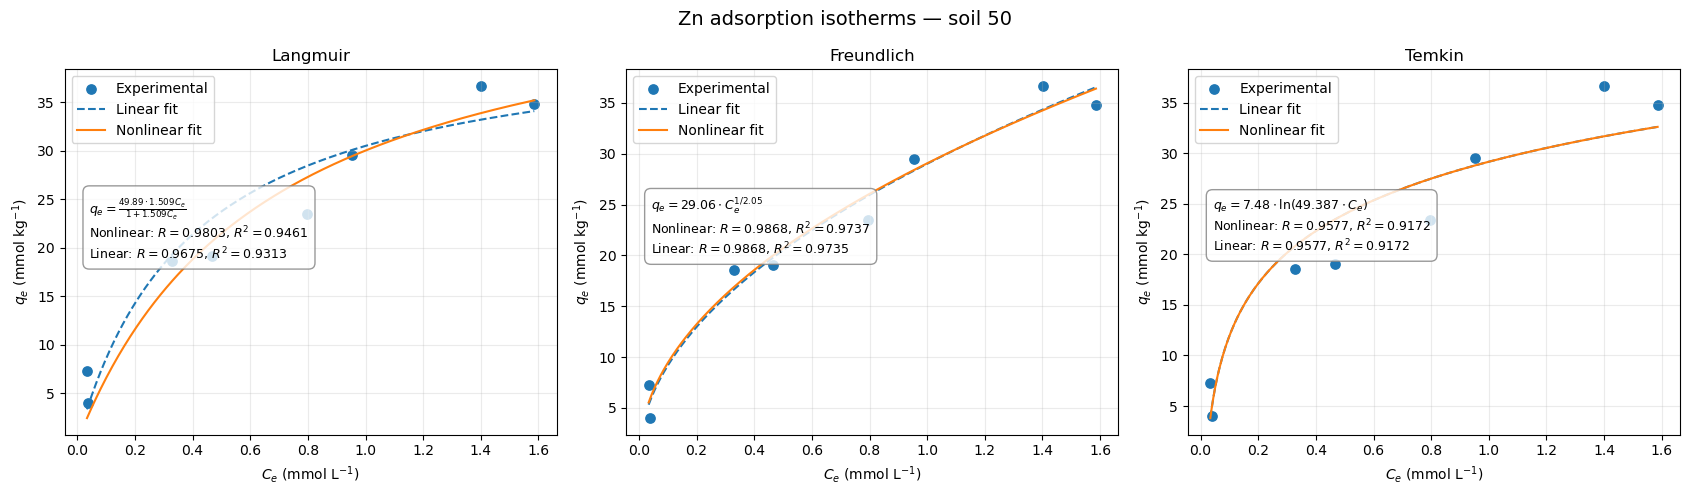

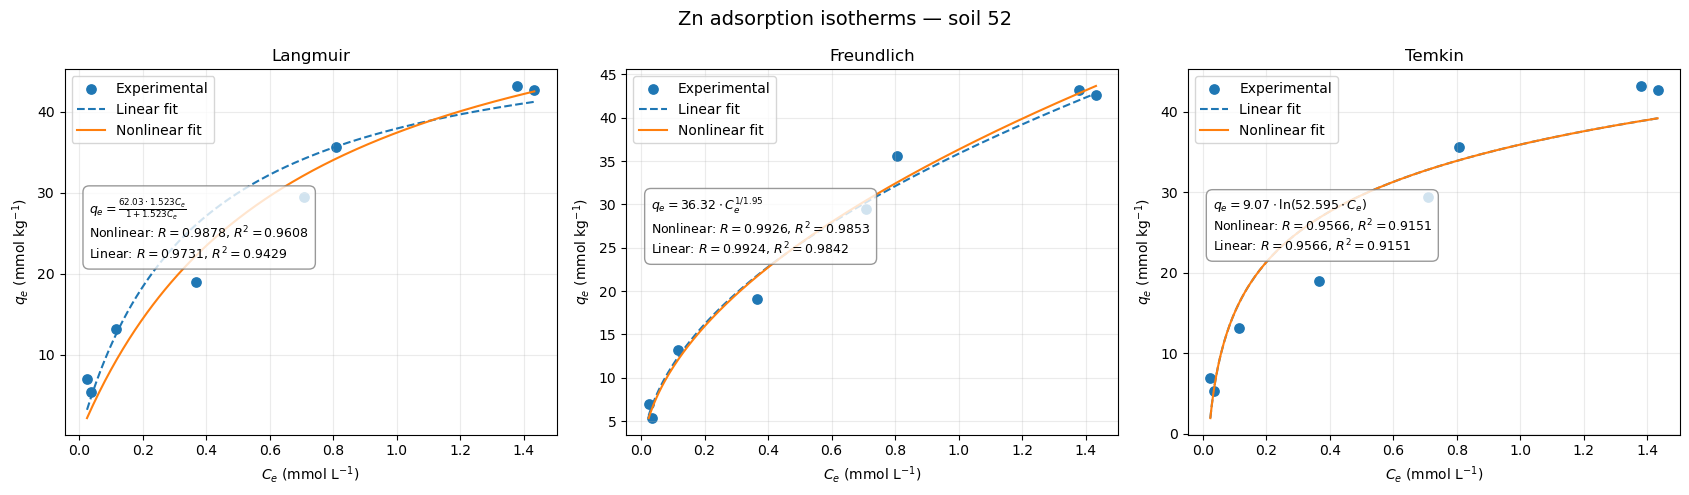

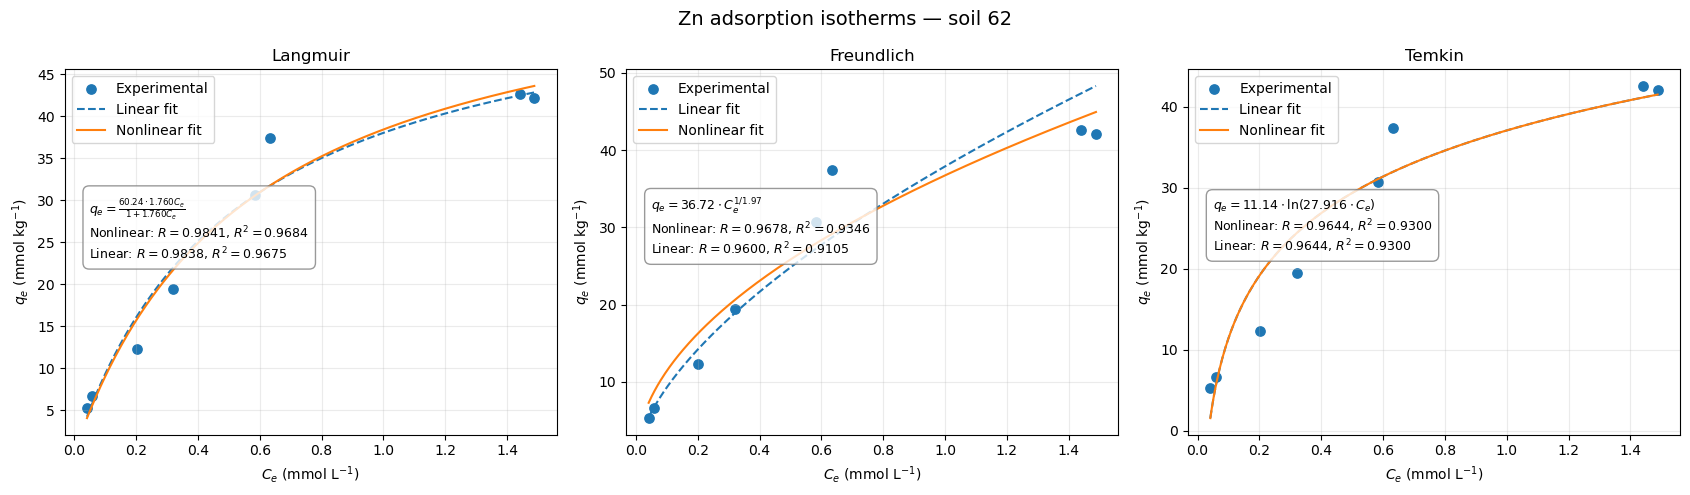

In [29]:
for sheet in TARGET_SHEETS:
    data = read_isotherm_data(DATA_FILE, sheet)
    Ce = data['Ce'].to_numpy(dtype=float)
    qe = data['qe'].to_numpy(dtype=float)
    linear = fit_linear_models(Ce, qe)
    nonlinear = fit_nonlinear_models(Ce, qe)

    x = np.linspace(Ce.min(), Ce.max(), 300)
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    for ax, model in zip(axes, NONLINEAR_MODELS):
        ax.scatter(Ce, qe, s=45, label='Experimental')

        if model == 'Langmuir':
            f = langmuir
        elif model == 'Freundlich':
            f = freundlich
        else:
            f = temkin

        # Linear parameters reconstructed on original scale.
        lp = linear[model]['params']
        if model == 'Langmuir':
            y_lin = f(x, lp['qm'], lp['KL'])
        elif model == 'Freundlich':
            y_lin = f(x, lp['KF'], lp['n'])
        else:
            y_lin = f(x, lp['A'], lp['B'])

        # Nonlinear fit parameters
        
        popt = nonlinear[model]['popt']
        y_non = f(x, *popt)
        

        # Non-linear equations
      
        if model == 'Langmuir':
            qm_n, KL_n = popt
            eq_text = f"$q_e = \\frac{{{qm_n:.2f} \\cdot {KL_n:.3f} C_e}}{{1 + {KL_n:.3f} C_e}}$"
        elif model == 'Freundlich':
            KF_n, n_n = popt
            eq_text = f"$q_e = {KF_n:.2f} \\cdot C_e^{{1 / {n_n:.2f}}}$"
        else:  # Temkin
            A_n, B_n = popt
            eq_text = f"$q_e = {B_n:.2f} \\cdot \\ln({A_n:.3f} \\cdot C_e)$"
       

        ax.plot(x, y_lin, '--', label='Linear fit')
        ax.plot(x, y_non, '-', label='Nonlinear fit')

        # Goodness-of-fit and correlation for both methods on the original qe scale
        st_lin = statistics(qe, linear[model]['pred'], k=2)
        st_non = statistics(qe, nonlinear[model]['pred'], k=2)

        # Show nonlinear equation together with correlation coefficient and R²
        eq_text_full = (
            eq_text
            + f"\nNonlinear: $R = {st_non['R']:.4f}$, $R^2 = {st_non['R2']:.4f}$"
            + f"\nLinear: $R = {st_lin['R']:.4f}$, $R^2 = {st_lin['R2']:.4f}$"
        )

        ax.text(0.05, 0.65, eq_text_full, transform=ax.transAxes, fontsize=9,
                verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                          alpha=0.8, edgecolor='gray'))

        ax.set_title(model)
        ax.set_xlabel(r"$C_e$ (mmol L$^{-1}$)")
        ax.set_ylabel(r"$q_e$ (mmol kg$^{-1}$)")

        ax.grid(alpha=0.25)
        ax.legend()

    fig.suptitle(f'Zn adsorption isotherms — soil {sheet}', fontsize=14)
    fig.tight_layout()
    plt.show()

In [30]:
residual_rows = []

for sheet in TARGET_SHEETS:
    data = read_isotherm_data(DATA_FILE, sheet)
    Ce = data['Ce'].to_numpy(float)
    qe = data['qe'].to_numpy(float)
    linear = fit_linear_models(Ce, qe)
    nonlinear = fit_nonlinear_models(Ce, qe)

    for model in NONLINEAR_MODELS:
        for method, pred in [('Linear', linear[model]['pred']), ('Nonlinear', nonlinear[model]['pred'])]:
            residuals = qe - pred
            residual_rows.append({
                'Soil': sheet,
                'Model': model,
                'Method': method,
                'Durbin_Watson': durbin_watson(residuals),
                'Mean_Residual': np.mean(residuals),
                'Max_Abs_Residual': np.max(np.abs(residuals))
            })

residual_table = pd.DataFrame(residual_rows)
display(residual_table.round(6))

,Soil,Model,Method,Durbin_Watson,Mean_Residual,Max_Abs_Residual
0,50,Langmuir,Linear,1.297087,-0.201441,4.961853
1,50,Langmuir,Nonlinear,1.308401,0.679852,4.841566
2,50,Freundlich,Linear,2.026581,0.111672,2.438006
3,50,Freundlich,Nonlinear,2.035630,0.007836,2.544548
4,50,Temkin,Linear,1.239088,0.000000,4.974410
5,50,Temkin,Nonlinear,1.239088,0.000000,4.974410
6,52,Langmuir,Linear,1.180844,-0.355293,6.987418
7,52,Langmuir,Nonlinear,1.189131,0.981690,4.848532
8,52,Freundlich,Linear,1.904197,0.201848,3.386614
9,52,Freundlich,Nonlinear,2.129046,0.053847,3.078057


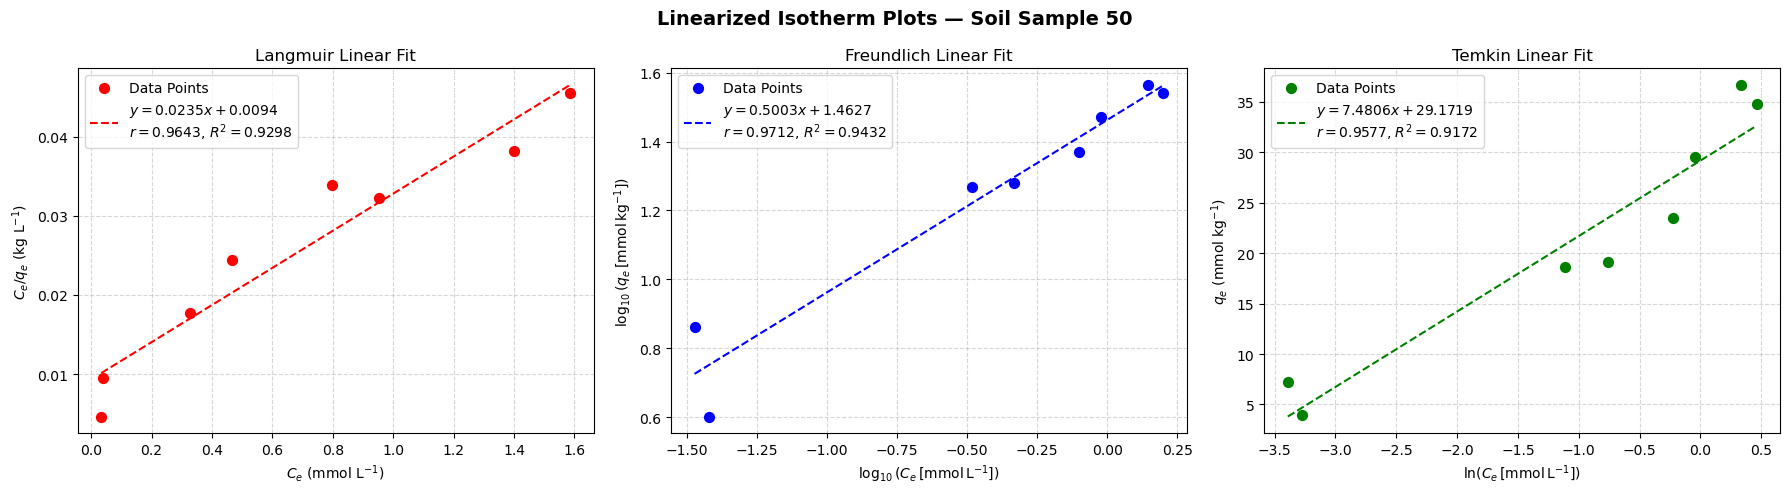

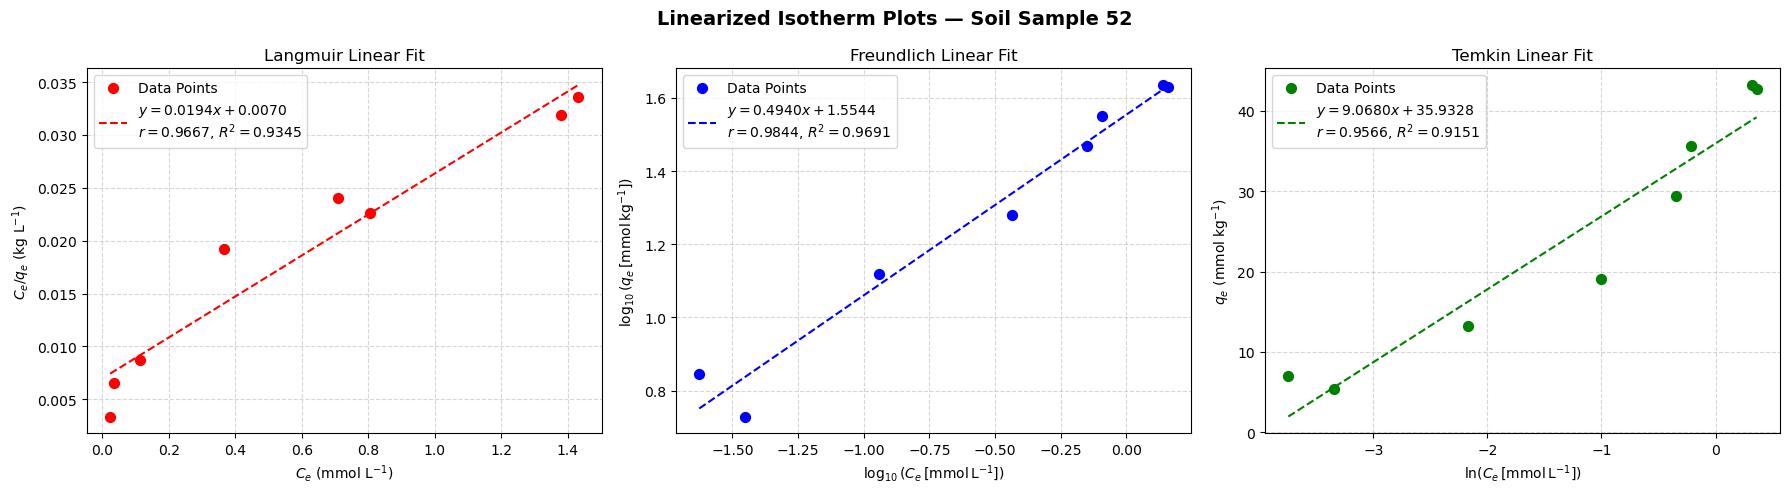

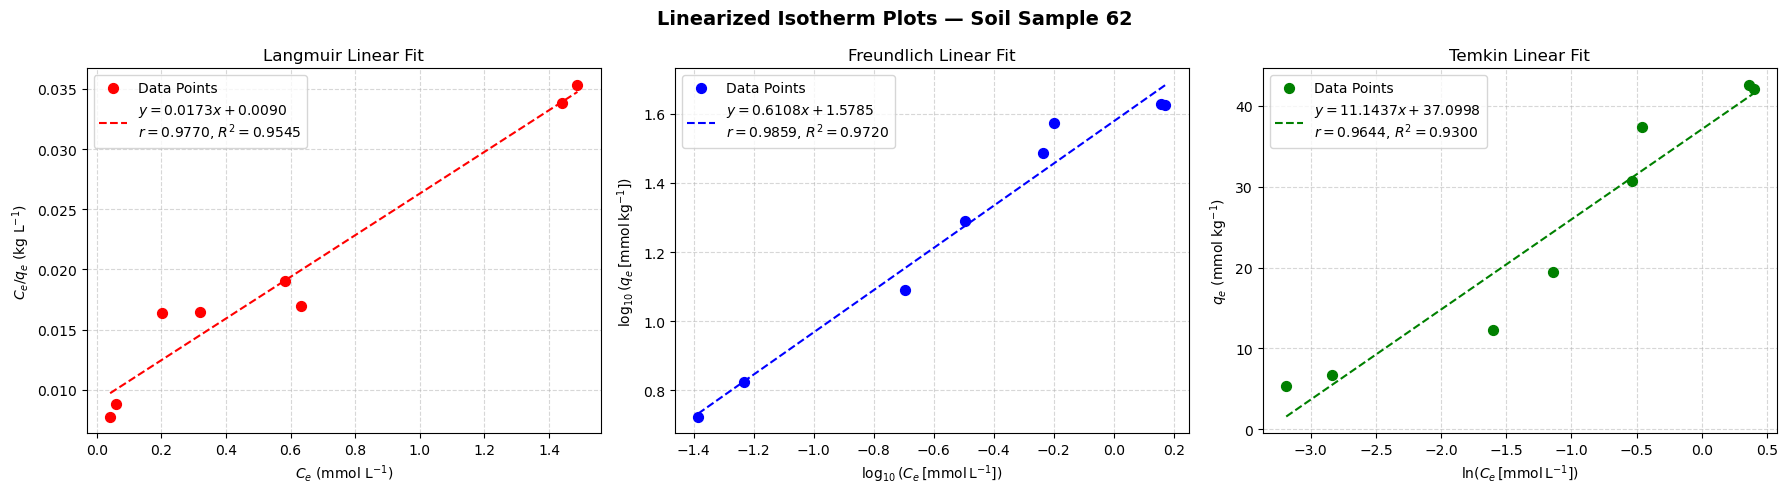

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

for sheet in TARGET_SHEETS:
    df = pd.read_excel(DATA_FILE, sheet_name=sheet)

    # Extraction of data
    sub_df = (
        df[["Treatment.1", "Ce mean", "qe(R1)", "qe(R2)", "qe(R3)"]]
        .dropna(subset=["Treatment.1"])
        .copy()
    )
    if "qe mean" in df.columns:
        sub_df["qe_mean"] = df["qe mean"].dropna().values[: len(sub_df)]
    else:
        sub_df["qe_mean"] = sub_df[["qe(R1)", "qe(R2)", "qe(R3)"]].mean(axis=1)

    Ce = sub_df["Ce mean"].values
    qe = sub_df["qe_mean"].values

    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    
    # 1. Langmuir Linear Plot: (Ce/qe) vs Ce
    
    x_lang = Ce
    y_lang = Ce / qe
    p_lang = np.polyfit(x_lang, y_lang, 1)
    yhat_lang = np.polyval(p_lang, x_lang)
    r2_lang = 1 - (np.sum((y_lang - yhat_lang) ** 2) / np.sum((y_lang - np.mean(y_lang)) ** 2))
    r_lang = np.corrcoef(x_lang, y_lang)[0, 1]
    
    x_smooth_lang = np.linspace(x_lang.min(), x_lang.max(), 100)
    axes[0].scatter(x_lang, y_lang, color="red", label="Data Points", s=50, zorder=5)
    axes[0].plot(x_smooth_lang, np.polyval(p_lang, x_smooth_lang), "r--", 
                 label=f"$y = {p_lang[0]:.4f}x + {p_lang[1]:.4f}$\n$r = {r_lang:.4f}$, $R^2 = {r2_lang:.4f}$")
    axes[0].set_title("Langmuir Linear Fit")
    axes[0].set_xlabel(r"$C_e$ (mmol L$^{-1}$)")
    axes[0].set_ylabel(r"$C_e/q_e$ (kg L$^{-1}$)")
    axes[0].grid(True, linestyle="--", alpha=0.5)
    axes[0].legend()

    
    # 2. Freundlich Linear Plot: log10(qe) vs log10(Ce)
   
    x_freu = np.log10(Ce)
    y_freu = np.log10(qe)
    p_freu = np.polyfit(x_freu, y_freu, 1)
    yhat_freu = np.polyval(p_freu, x_freu)
    r2_freu = 1 - (np.sum((y_freu - yhat_freu) ** 2) / np.sum((y_freu - np.mean(y_freu)) ** 2))
    r_freu = np.corrcoef(x_freu, y_freu)[0, 1]
    
    x_smooth_freu = np.linspace(x_freu.min(), x_freu.max(), 100)
    axes[1].scatter(x_freu, y_freu, color="blue", label="Data Points", s=50, zorder=5)
    axes[1].plot(x_smooth_freu, np.polyval(p_freu, x_smooth_freu), "b--", 
                 label=f"$y = {p_freu[0]:.4f}x + {p_freu[1]:.4f}$\n$r = {r_freu:.4f}$, $R^2 = {r2_freu:.4f}$")
    axes[1].set_title("Freundlich Linear Fit")
    axes[1].set_xlabel(r"$\log_{10}(C_e\,[\mathrm{mmol\,L^{-1}}])$")
    axes[1].set_ylabel(r"$\log_{10}(q_e\,[\mathrm{mmol\,kg^{-1}}])$")
    axes[1].grid(True, linestyle="--", alpha=0.5)
    axes[1].legend()

    
    # 3. Temkin Linear Plot: qe vs ln(Ce)
    
    x_temk = np.log(Ce)
    y_temk = qe
    p_temk = np.polyfit(x_temk, y_temk, 1)
    yhat_temk = np.polyval(p_temk, x_temk)
    r2_temk = 1 - (np.sum((y_temk - yhat_temk) ** 2) / np.sum((y_temk - np.mean(y_temk)) ** 2))
    r_temk = np.corrcoef(x_temk, y_temk)[0, 1]
    
    x_smooth_temk = np.linspace(x_temk.min(), x_temk.max(), 100)
    axes[2].scatter(x_temk, y_temk, color="green", label="Data Points", s=50, zorder=5)
    axes[2].plot(x_smooth_temk, np.polyval(p_temk, x_smooth_temk), "g--", 
                 label=f"$y = {p_temk[0]:.4f}x + {p_temk[1]:.4f}$\n$r = {r_temk:.4f}$, $R^2 = {r2_temk:.4f}$")
    axes[2].set_title("Temkin Linear Fit")
    axes[2].set_xlabel(r"$\ln(C_e\,[\mathrm{mmol\,L^{-1}}])$")
    axes[2].set_ylabel(r"$q_e$ (mmol kg$^{-1}$)")
    axes[2].grid(True, linestyle="--", alpha=0.5)
    axes[2].legend()

    # Setting Plot
    fig.suptitle(f"Linearized Isotherm Plots — Soil Sample {sheet}", fontsize=14, fontweight="bold")
    fig.tight_layout()
    plt.savefig(f"Linearized_Plots_Soil_{sheet}.png", dpi=300)
    plt.show()

In [32]:
OUTPUT_FILE = 'Zn_Linear_vs_Nonlinear_Comparison.xlsx'
with pd.ExcelWriter(OUTPUT_FILE, engine='openpyxl') as writer:
    parameters.to_excel(writer, sheet_name='Nonlinear_Parameters', index=False)
    comparison.to_excel(writer, sheet_name='Model_Comparison', index=False)
    direction_table.to_excel(writer, sheet_name='Method_Direction', index=False)
    residual_table.to_excel(writer, sheet_name='Residual_Diagnostics', index=False)

print(f'Saved: {OUTPUT_FILE}')

Saved: Zn_Linear_vs_Nonlinear_Comparison.xlsx
